# Model Performance Comparison — Notebook

This notebook loads the saved metrics from the baseline, XGBoost, and LightGBM
training notebooks, compares them side by side, and produces comparison charts.

Run the training notebooks (`06`, `07`, `08`) first so the metrics CSV files exist,
then run this notebook top to bottom.

## 1. Configure paths

Update `WORKSPACE_ROOT` below if your workspace isn't auto-detected (e.g. if you mounted
Google Drive, point it at the Drive folder containing `reports/model_reports/...`).

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_workspace_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    for path in [current, *current.parents]:
        if (path / "data" / "processed" / "baseline_modeling_dataset.csv.gz").exists():
            return path

    return current


WORKSPACE_ROOT = find_workspace_root()

# --- If auto-detection doesn't find your workspace (common in Colab), set it manually: ---
# WORKSPACE_ROOT = Path("/content/drive/MyDrive/your-project-folder")

REPORTS_DIR = WORKSPACE_ROOT / "reports" / "model_reports"
FIGURES_DIR = WORKSPACE_ROOT / "reports" / "figures"
OUTPUT_COMPARISON_FILE = REPORTS_DIR / "model_comparison.csv"
MODEL_METRIC_FILES = {
    "Baseline SGD Logistic": REPORTS_DIR / "baseline_model_metrics.csv",
    "XGBoost": REPORTS_DIR / "xgboost_model_metrics.csv",
    "LightGBM": REPORTS_DIR / "lightgbm_model_metrics.csv",
}

print("Workspace root:", WORKSPACE_ROOT)
print("Reports directory:", REPORTS_DIR)
print("Figures directory:", FIGURES_DIR)

Workspace root: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai
Reports directory: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports
Figures directory: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures


In [4]:
def create_output_directories() -> None:
    REPORTS_DIR.mkdir(parents=True, exist_ok=True)
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)


create_output_directories()
print("Output directories ready:")
for d in [REPORTS_DIR, FIGURES_DIR]:
    print(f"  - {d}")

Output directories ready:
  - C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports
  - C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures


## 2. Load metrics for each model

In [5]:
def load_model_metrics() -> pd.DataFrame:
    records = []
    for model_name, metrics_file in MODEL_METRIC_FILES.items():
        if not metrics_file.exists():
            raise FileNotFoundError(
                f"Missing metrics file: {metrics_file}. "
                f"Run the training script for {model_name} first."
            )

        metrics_df = pd.read_csv(metrics_file)
        record = {"model": model_name}
        for _, row in metrics_df.iterrows():
            record[row["metric"]] = row["value"]
        records.append(record)

    comparison_df = pd.DataFrame(records)
    metric_order = [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "average_precision_pr_auc",
    ]
    return comparison_df[metric_order]


comparison_df = load_model_metrics()
print(f"Loaded metrics for {len(comparison_df)} models.")
comparison_df

Loaded metrics for 3 models.


,model,accuracy,precision,recall,f1_score,roc_auc,average_precision_pr_auc
0,Baseline SGD Logistic,0.778576,0.109218,0.744496,0.190491,0.845530,0.392479
1,XGBoost,0.862473,0.174742,0.787080,0.285991,0.903718,0.535004
2,LightGBM,0.889821,0.217665,0.828212,0.344730,0.936729,0.633026


## 3. Identify the best model per metric

In [6]:
def identify_best_models(comparison_df: pd.DataFrame) -> pd.DataFrame:
    metric_columns = [
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "average_precision_pr_auc",
    ]
    records = []
    for metric in metric_columns:
        best_row = comparison_df.loc[comparison_df[metric].idxmax()]
        records.append(
            {
                "metric": metric,
                "best_model": best_row["model"],
                "best_value": best_row[metric],
            }
        )
    return pd.DataFrame(records)


best_models_df = identify_best_models(comparison_df)
best_models_df

,metric,best_model,best_value
0,accuracy,LightGBM,0.889821
1,precision,LightGBM,0.217665
2,recall,LightGBM,0.828212
3,f1_score,LightGBM,0.344730
4,roc_auc,LightGBM,0.936729
5,average_precision_pr_auc,LightGBM,0.633026


## 4. Save the comparison table

In [7]:
comparison_df.to_csv(OUTPUT_COMPARISON_FILE, index=False)
print(f"Model comparison saved to: {OUTPUT_COMPARISON_FILE}")

Model comparison saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports\model_comparison.csv


## 5. Chart — all metrics by model

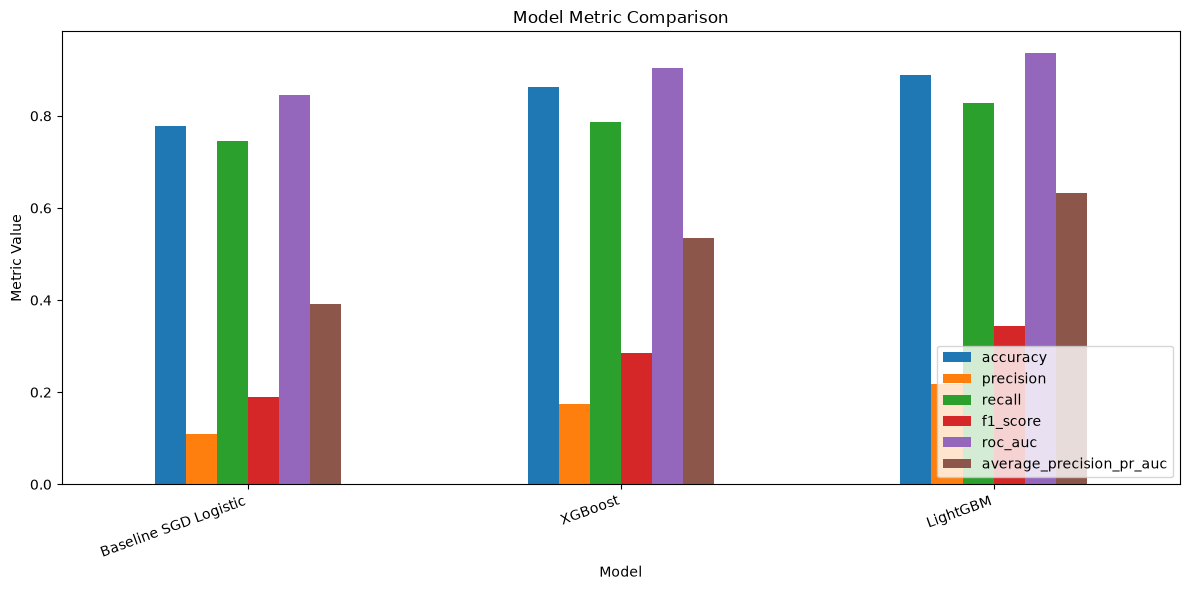

Figure saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures\model_metric_comparison.png


In [8]:
def plot_model_metric_comparison(comparison_df: pd.DataFrame) -> None:
    plot_df = comparison_df.set_index("model")[
        [
            "accuracy",
            "precision",
            "recall",
            "f1_score",
            "roc_auc",
            "average_precision_pr_auc",
        ]
    ]
    plt.figure(figsize=(12, 6))
    plot_df.plot(kind="bar", ax=plt.gca())
    plt.title("Model Metric Comparison")
    plt.xlabel("Model")
    plt.ylabel("Metric Value")
    plt.xticks(rotation=20, ha="right")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "model_metric_comparison.png")
    plt.show()


plot_model_metric_comparison(comparison_df)
print(f"Figure saved to: {FIGURES_DIR / 'model_metric_comparison.png'}")

## 6. Chart — PR-AUC comparison

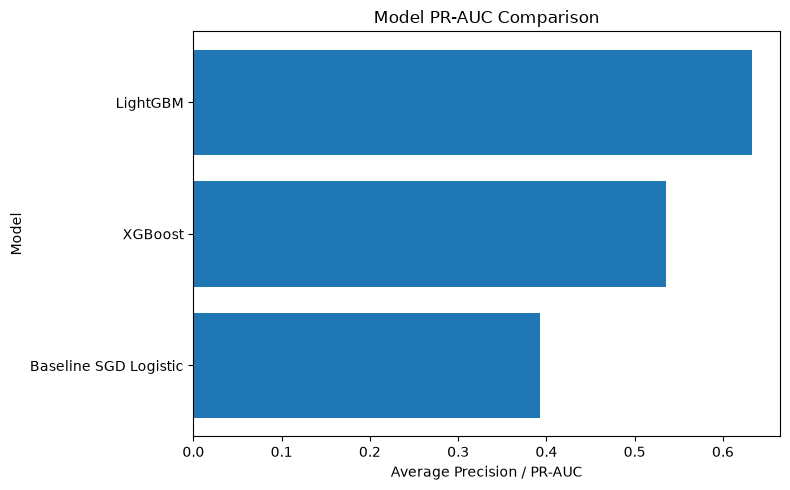

Figure saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures\model_pr_auc_comparison.png


In [9]:
def plot_pr_auc_comparison(comparison_df: pd.DataFrame) -> None:
    plot_df = comparison_df.sort_values("average_precision_pr_auc")
    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["model"], plot_df["average_precision_pr_auc"])
    plt.title("Model PR-AUC Comparison")
    plt.xlabel("Average Precision / PR-AUC")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "model_pr_auc_comparison.png")
    plt.show()


plot_pr_auc_comparison(comparison_df)
print(f"Figure saved to: {FIGURES_DIR / 'model_pr_auc_comparison.png'}")

## 7. Chart — precision and recall comparison

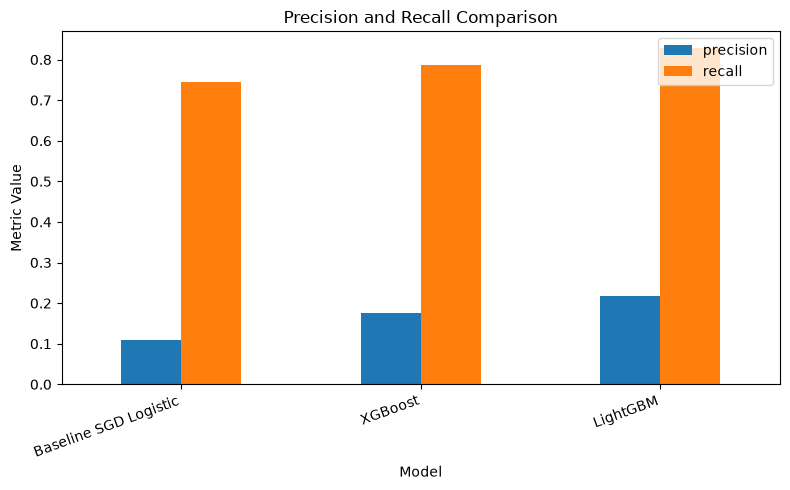

Figure saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures\model_precision_recall_comparison.png


In [10]:
def plot_precision_recall_comparison(comparison_df: pd.DataFrame) -> None:
    plot_df = comparison_df.set_index("model")[["precision", "recall"]]
    plt.figure(figsize=(8, 5))
    plot_df.plot(kind="bar", ax=plt.gca())
    plt.title("Precision and Recall Comparison")
    plt.xlabel("Model")
    plt.ylabel("Metric Value")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "model_precision_recall_comparison.png")
    plt.show()


plot_precision_recall_comparison(comparison_df)
print(f"Figure saved to: {FIGURES_DIR / 'model_precision_recall_comparison.png'}")

## 8. Summary

In [11]:
print("Model Performance Comparison")
print("=" * 80)
print(comparison_df)
print()
print("Best model by metric:")
print(best_models_df)
print()
best_pr_auc_model = best_models_df[
    best_models_df["metric"] == "average_precision_pr_auc"
]["best_model"].iloc[0]
print(f"Best model by PR-AUC: {best_pr_auc_model}")
print()
print(f"Model comparison saved to: {OUTPUT_COMPARISON_FILE}")
print(f"Figures saved to: {FIGURES_DIR}")

Model Performance Comparison
                   model  accuracy  precision    recall  f1_score   roc_auc  \
0  Baseline SGD Logistic  0.778576   0.109218  0.744496  0.190491  0.845530   
1                XGBoost  0.862473   0.174742  0.787080  0.285991  0.903718   
2               LightGBM  0.889821   0.217665  0.828212  0.344730  0.936729   

   average_precision_pr_auc  
0                  0.392479  
1                  0.535004  
2                  0.633026  

Best model by metric:
                     metric best_model  best_value
0                  accuracy   LightGBM    0.889821
1                 precision   LightGBM    0.217665
2                    recall   LightGBM    0.828212
3                  f1_score   LightGBM    0.344730
4                   roc_auc   LightGBM    0.936729
5  average_precision_pr_auc   LightGBM    0.633026

Best model by PR-AUC: LightGBM

Model comparison saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports\model_comparison.csv
